In [1]:
import sys
sys.path.insert(0, '../lib')
import pandas
import pandas as pd
import numpy as np
from sklearn import preprocessing as sk_preprocessing
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns
import random
import scipy
from statsmodels.stats.multitest import multipletests
import matplotlib as mpl

import common_data
import common_plots
import sankey

NB_OF_CLUSTERS = 13

RANDOM_SEED = 42

LABELS_PATH = common_data.CLINICAL_LABELS

In [2]:
%config InlineBackend.figure_format = "retina"

In [3]:
common_plots.setup_plotting()

In [4]:
pd.options.display.max_columns = 200

In [5]:
labels = common_data.get_sc_categorical_covariates()
numericals = common_data.get_sc_numerical_covariates()

We are not analyzing VAP onset, because they have too few negative labels in single cell

In [6]:
labels.drop(columns=['VAP_onset_within_7d'], inplace=True)

In [7]:
categorical_features = labels.columns

In [8]:
labels['bal_barcode'] = labels.index
labels = labels.set_index('bal_barcode')
numericals['bal_barcode'] = numericals.index
numericals = numericals.set_index('bal_barcode')

In [9]:
sc_cluster_data = pandas.read_csv(
    common_data.SC_CLUSTERS
)

In [10]:
cell_columns = [
    'LYMPHO_NNORMED:B cells',
    'LYMPHO_NNORMED:CD4 T cells',
    'LYMPHO_NNORMED:CD8 T cells',
    'LYMPHO_NNORMED:Classical monocytes-1 CCR2',
    'LYMPHO_NNORMED:Classical monocytes-2 IL1B',
    'LYMPHO_NNORMED:DC1',
    'LYMPHO_NNORMED:DC2',
    #'LYMPHO_NNORMED:Hematopoietic stem cells',
    'LYMPHO_NNORMED:MRC1+C1QA+',
    'LYMPHO_NNORMED:MRC1+C1QA-',
    'LYMPHO_NNORMED:Migratory DC',
    'LYMPHO_NNORMED:NUPR1+ Macs',
    'LYMPHO_NNORMED:Non-classical monocytes',
    'LYMPHO_NNORMED:Perivascular macrophages',
    'LYMPHO_NNORMED:Plasma cells',
    'LYMPHO_NNORMED:Proliferating CD4 T cells',
    'LYMPHO_NNORMED:Proliferating CD8 T cells',
    'LYMPHO_NNORMED:Proliferating NUPR1+ Macs',
    'LYMPHO_NNORMED:Proliferating gdT cells',
    'LYMPHO_NNORMED:Proliferating plasma cells',
    'LYMPHO_NNORMED:Tregs',
    'LYMPHO_NNORMED:gdT cells',
    'LYMPHO_NNORMED:pDC',
    'LYMPHO_NNORMED:Neutrophils percent',
]

In [11]:
cell_columns_x = [col_name + '_x' for col_name in cell_columns]

In [12]:
full_df = pandas.merge(
    sc_cluster_data[
        cell_columns
        + ['bal_barcode', 'Neutrophil Cluster', 'perturbation_groups', 'clusters_final']
    ],
    labels,
    on='bal_barcode',
    how='left'
)

In [13]:
sc_cluster_data.shape

(241, 211)

In [14]:
full_df.shape

(241, 52)

In [15]:
full_df = pandas.merge(
    full_df,
    numericals,
    on='bal_barcode',
    how='left'
)

In [16]:
full_df.shape

(241, 90)

In [17]:
cluster_scores = np.array([
    int(row_['clusters_final']) * 10 + row_['Neutrophil Cluster']
    for _, row_ in full_df.iterrows()
])

In [18]:
cluster_sorting = cluster_scores.argsort()

In [19]:
full_df['clusters_final'][cluster_sorting]

239     0
77      0
231     0
203     0
80      1
       ..
39     12
33     12
32     12
25     12
23     12
Name: clusters_final, Length: 241, dtype: int64

In [20]:
col_names = [''] * len(cluster_sorting)

for ind_ in range(NB_OF_CLUSTERS):
    selector = full_df['clusters_final'][cluster_sorting].to_numpy() == ind_
    start_index = None
    for start_ in range(len(selector)):
        if selector[start_]:
            start_index = start_
            break
    end_index = start_index

    for end_ in range(start_index + 1, len(selector)):
        if selector[end_]:
            end_index = end_
    print(start_index, end_index, ind_)
    cluster_name_ind = int((start_index + end_index) / 2.0)
    if end_index - start_index > 4:
        col_names[cluster_name_ind] = str(ind_)
    col_names[start_index] = '|'
    #col_names[end_index] = '|'

0 3 0
4 54 1
55 56 2
57 106 3
107 128 4
129 143 5
144 150 6
151 181 7
182 199 8
200 216 9
217 229 10
230 231 11
232 240 12


In [21]:
full_df.clusters_final.value_counts().sort_index()

0      4
1     51
2      2
3     50
4     22
5     15
6      7
7     31
8     18
9     17
10    13
11     2
12     9
Name: clusters_final, dtype: int64

In [22]:
scaler = sk_preprocessing.StandardScaler()
flow_data_nn = (full_df[cell_columns]).copy() ** 0.5
flow_data_nn[cell_columns] = scaler.fit_transform(flow_data_nn)

In [23]:
full_df['clusters_final'].max()

12

In [24]:
detailed_colors = {
    'NPC': '#256b33',
    'Early SARS-CoV-2': '#18b3e2',
    'Late SARS-CoV-2': '#2188a8',
    'Early SARS-CoV-2; Gram+': '#cc43f2',
    'Late SARS-CoV-2; Gram+': '#9621b7',
    'discard': '#cfcfcf',
    'Pseudomonas aeruginosa; SARS-CoV-2': '#8f56bf',
    'Gram+': '#ef7267',
    'Pseudomonas aeruginosa': '#d83122',
    'Gram-*; Gram+': '#af3407',
    'Gram-*': '#c15a34'
}
col_colors = full_df.Pathogen_groups.replace(detailed_colors).to_frame()

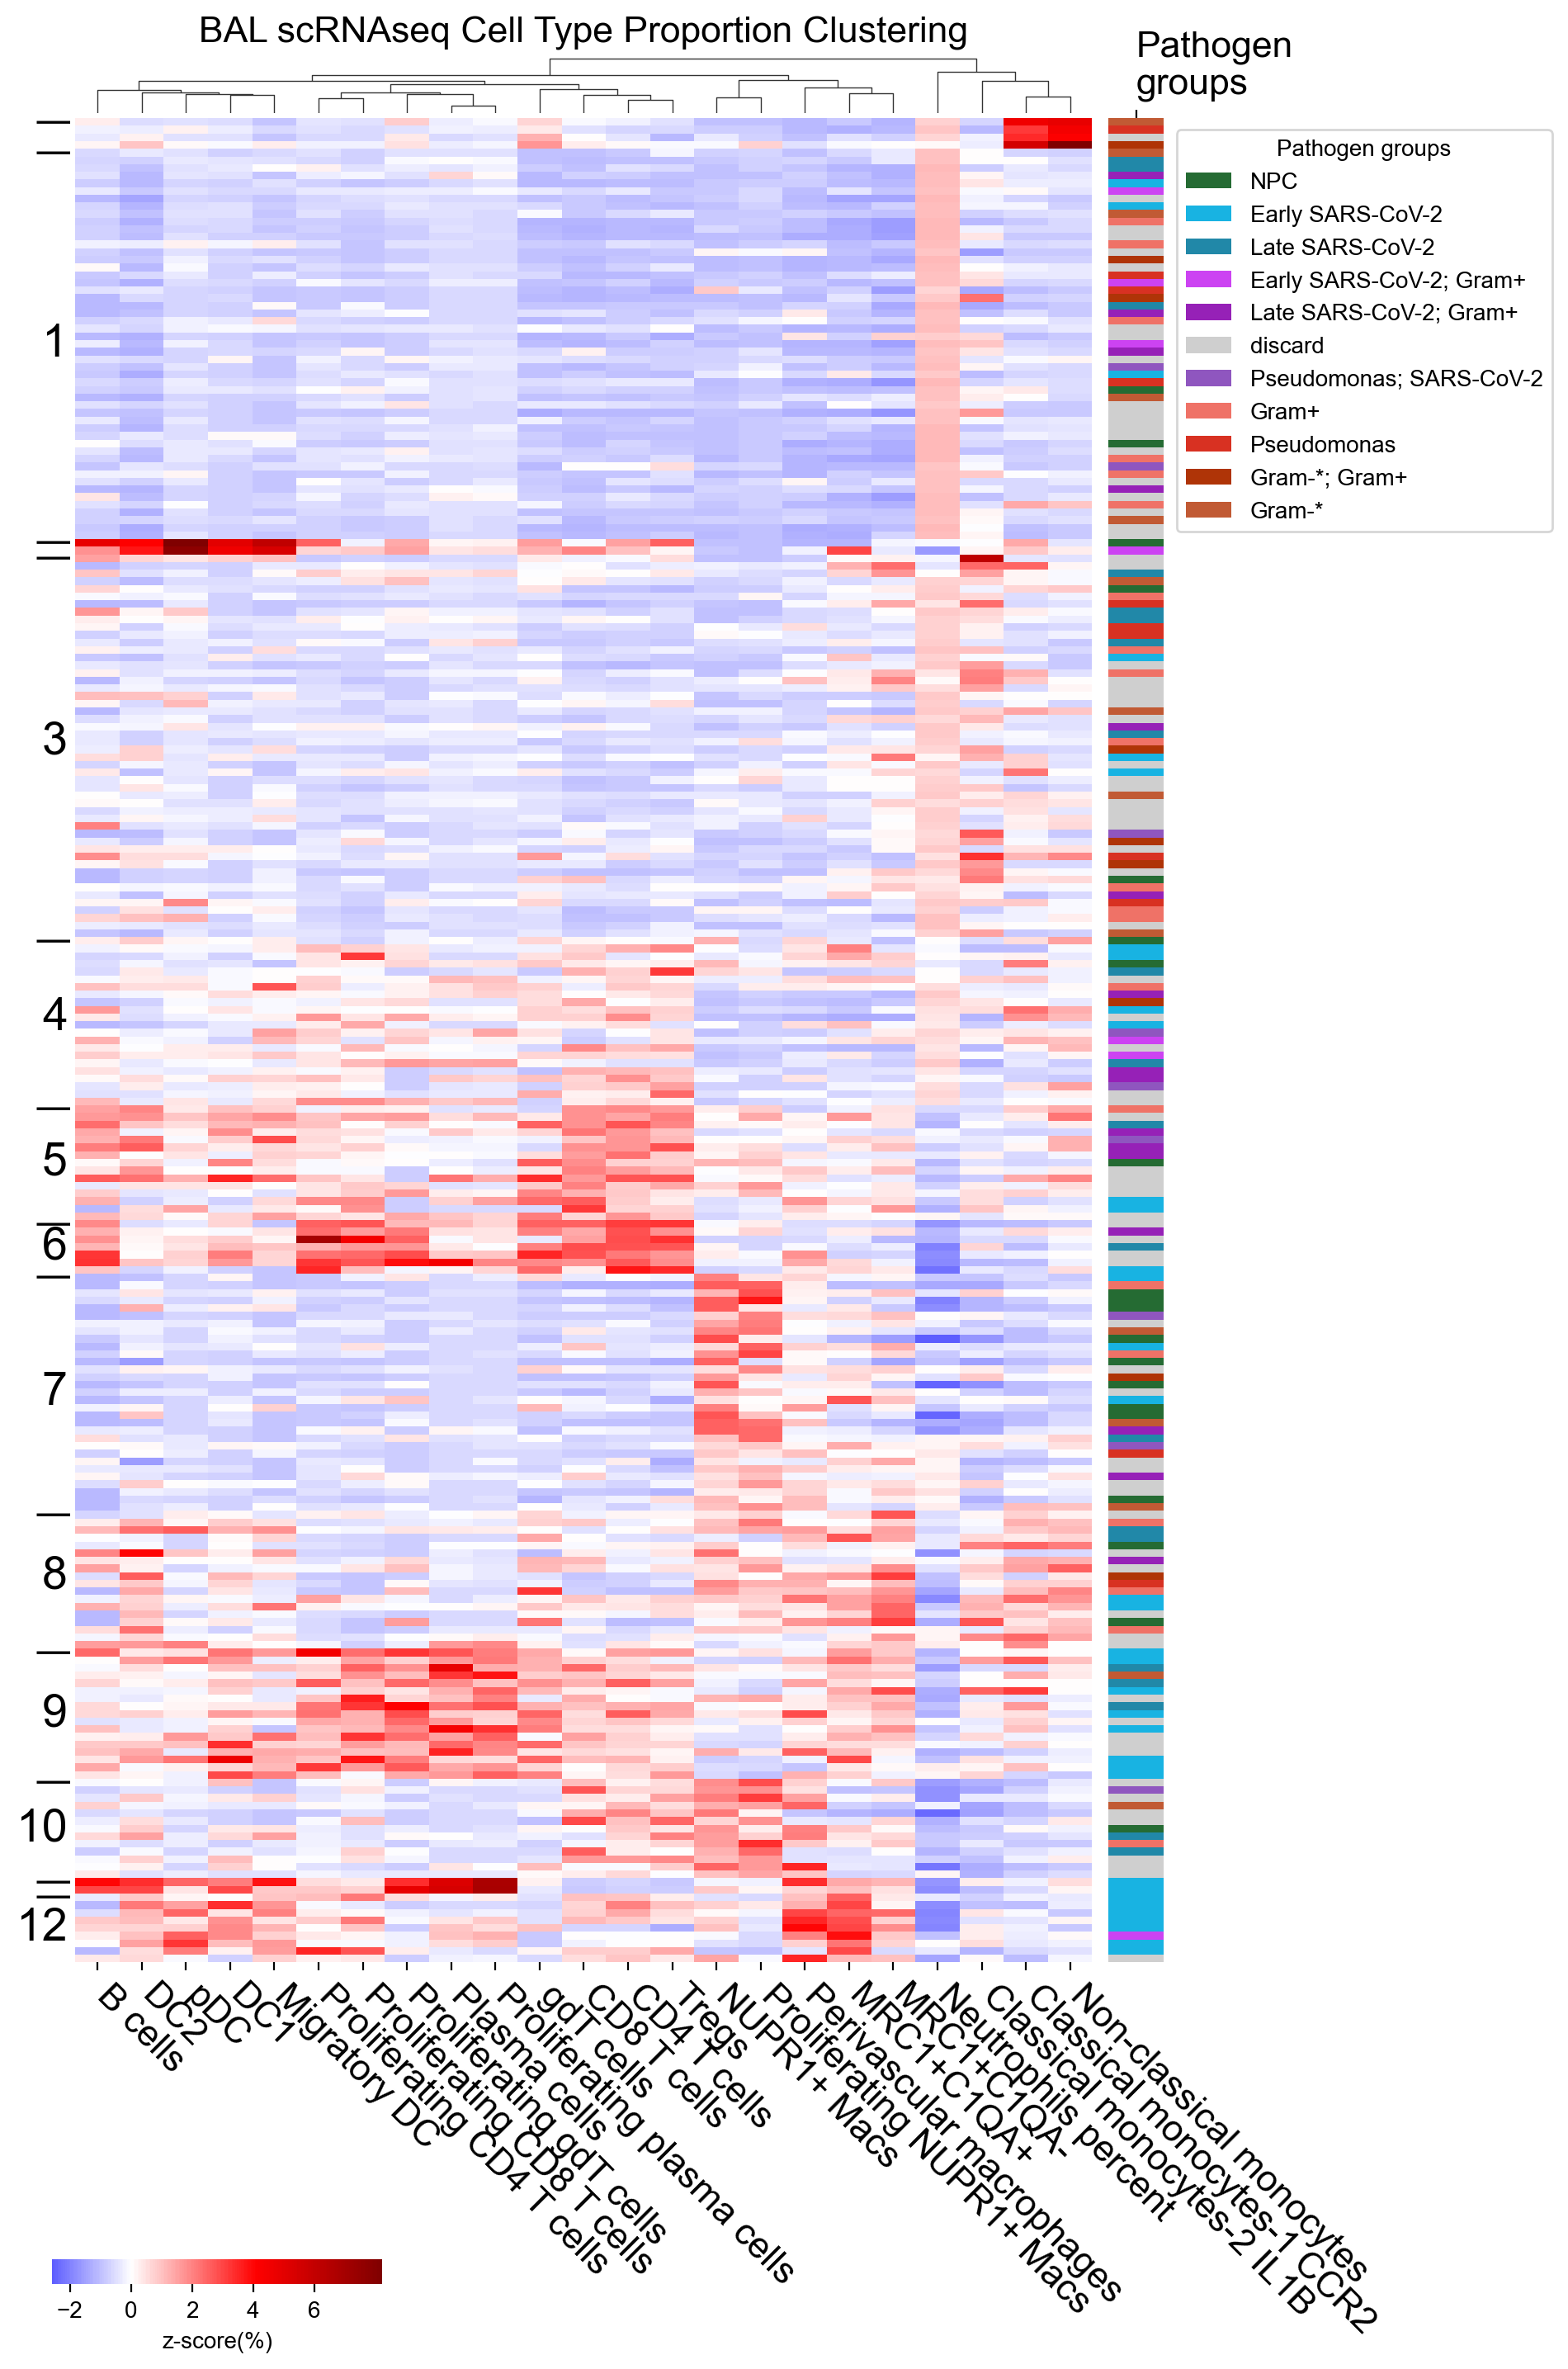

In [25]:
clustermap = sns.clustermap(
    flow_data_nn[cell_columns].loc[cluster_sorting],
    z_score=1,
    method='complete',
    metric='cityblock',
    cmap='seismic',
    row_cluster=False,
    figsize=(10, 15),
    colors_ratio=0.05,
    dendrogram_ratio=0.03,
    center=0,
    yticklabels=col_names,
    xticklabels=[name[15:] if name.startswith('LYMPHO_NNORMED:') else name for name in cell_columns],
    row_colors=col_colors,
    cbar_pos=(0, 0.02, 0.2, 0.01),
    cbar_kws=dict(
        label='z-score(%)',
        orientation='horizontal',
        ticks=[-2, 0, 2, 4, 6]
    ),
)

clustermap.ax_row_dendrogram.set_visible(False)
_ = clustermap.ax_col_dendrogram.set_title('BAL scRNAseq Cell Type Proportion Clustering', fontsize=16)
clustermap.ax_heatmap.set_yticklabels(
    clustermap.ax_heatmap.get_ymajorticklabels(),
    fontsize=16,
    rotation=90
)
clustermap.ax_heatmap.set_xticklabels(
    clustermap.ax_heatmap.get_xmajorticklabels(),
    fontsize=16,
    rotation=315,
    ha='left'
)
trans = mpl.transforms.Affine2D().translate(-8, 0)
for t in clustermap.ax_heatmap.get_xticklabels():
    t.set_transform(t.get_transform() + trans)

clustermap.ax_heatmap.tick_params(
    axis='y',
    size=0,
    left=True,
    right=False,
    labelleft=True,
    labelright=False
)
clustermap.ax_row_colors.tick_params(
    axis='x',
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
)
clustermap.ax_row_colors.set_xticklabels(['Pathogen\ngroups'], size=16)
for t in clustermap.ax_row_colors.get_xticklabels():
    t.set_ha('left')
clustermap.ax_row_colors.legend(
    handles=[
        mpl.patches.Patch(fc=v, label=k.replace(' aeruginosa', ''))
        for k, v
        in detailed_colors.items()
    ],
    ncols=1,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    title='Pathogen groups'
)

for t in clustermap.ax_heatmap.get_yticklabels():
    t.set_va('bottom')
    if t.get_text() != '' and t.get_text() != '|':
        t.set_rotation(0)
        t.set_size(20)
        t.set_va('center')

clustermap.fig.subplots_adjust(left=0.01, right=0.68, bottom=0.18, top=0.95)

p = clustermap.ax_row_colors.get_position()
w = p.x1 - p.x0
p_hm = clustermap.ax_heatmap.get_position()
p.x0 = p_hm.x1 + 0.01
p.x1 = p.x0 + w
clustermap.ax_row_colors.set_position(p)

clustermap.cax.set_position((0.05, 0.05, 0.2, 0.01))

clustermap.fig.savefig('10Hd_scrnaseq_clusters.pdf')

In [26]:
coarse_colors = {
    'NPC': '#42c95d',
    'viral': '#4638e2',
    'bacterial': '#c93434',
    'superinfection': '#cca135',
    'discard': 'white'
}

In [27]:
col_colors['Pathogen_groups'] = full_df.Pathogen_groups.replace({
    'NPC': coarse_colors['NPC'],
    'Early SARS-CoV-2': coarse_colors['viral'],
    'Late SARS-CoV-2': coarse_colors['viral'],
    'Early SARS-CoV-2; Gram+': coarse_colors['superinfection'],
    'Late SARS-CoV-2; Gram+': coarse_colors['superinfection'],
    'discard': coarse_colors['discard'],
    'Pseudomonas aeruginosa; SARS-CoV-2': coarse_colors['superinfection'],
    'Gram+': coarse_colors['bacterial'],
    'Pseudomonas aeruginosa': coarse_colors['bacterial'],
    'Gram-*; Gram+': coarse_colors['bacterial'],
    'Gram-*': coarse_colors['bacterial']
})

In [28]:
CELL_TYPES_DISPLAY = {
    'NUPR1+ Macs': 'NUPR1+ AM',
    'Proliferating NUPR1+ Macs': 'Proliferating NUPR1+ AM',
    'MRC1+C1QA+': 'MRC1+C1QA+ AM',
    'MRC1+C1QA-': 'MRC1+C1QA– AM',
    'gdT cells': 'γδT cells',
    'Proliferating gdT cells': 'Proliferating γδT cells'
}

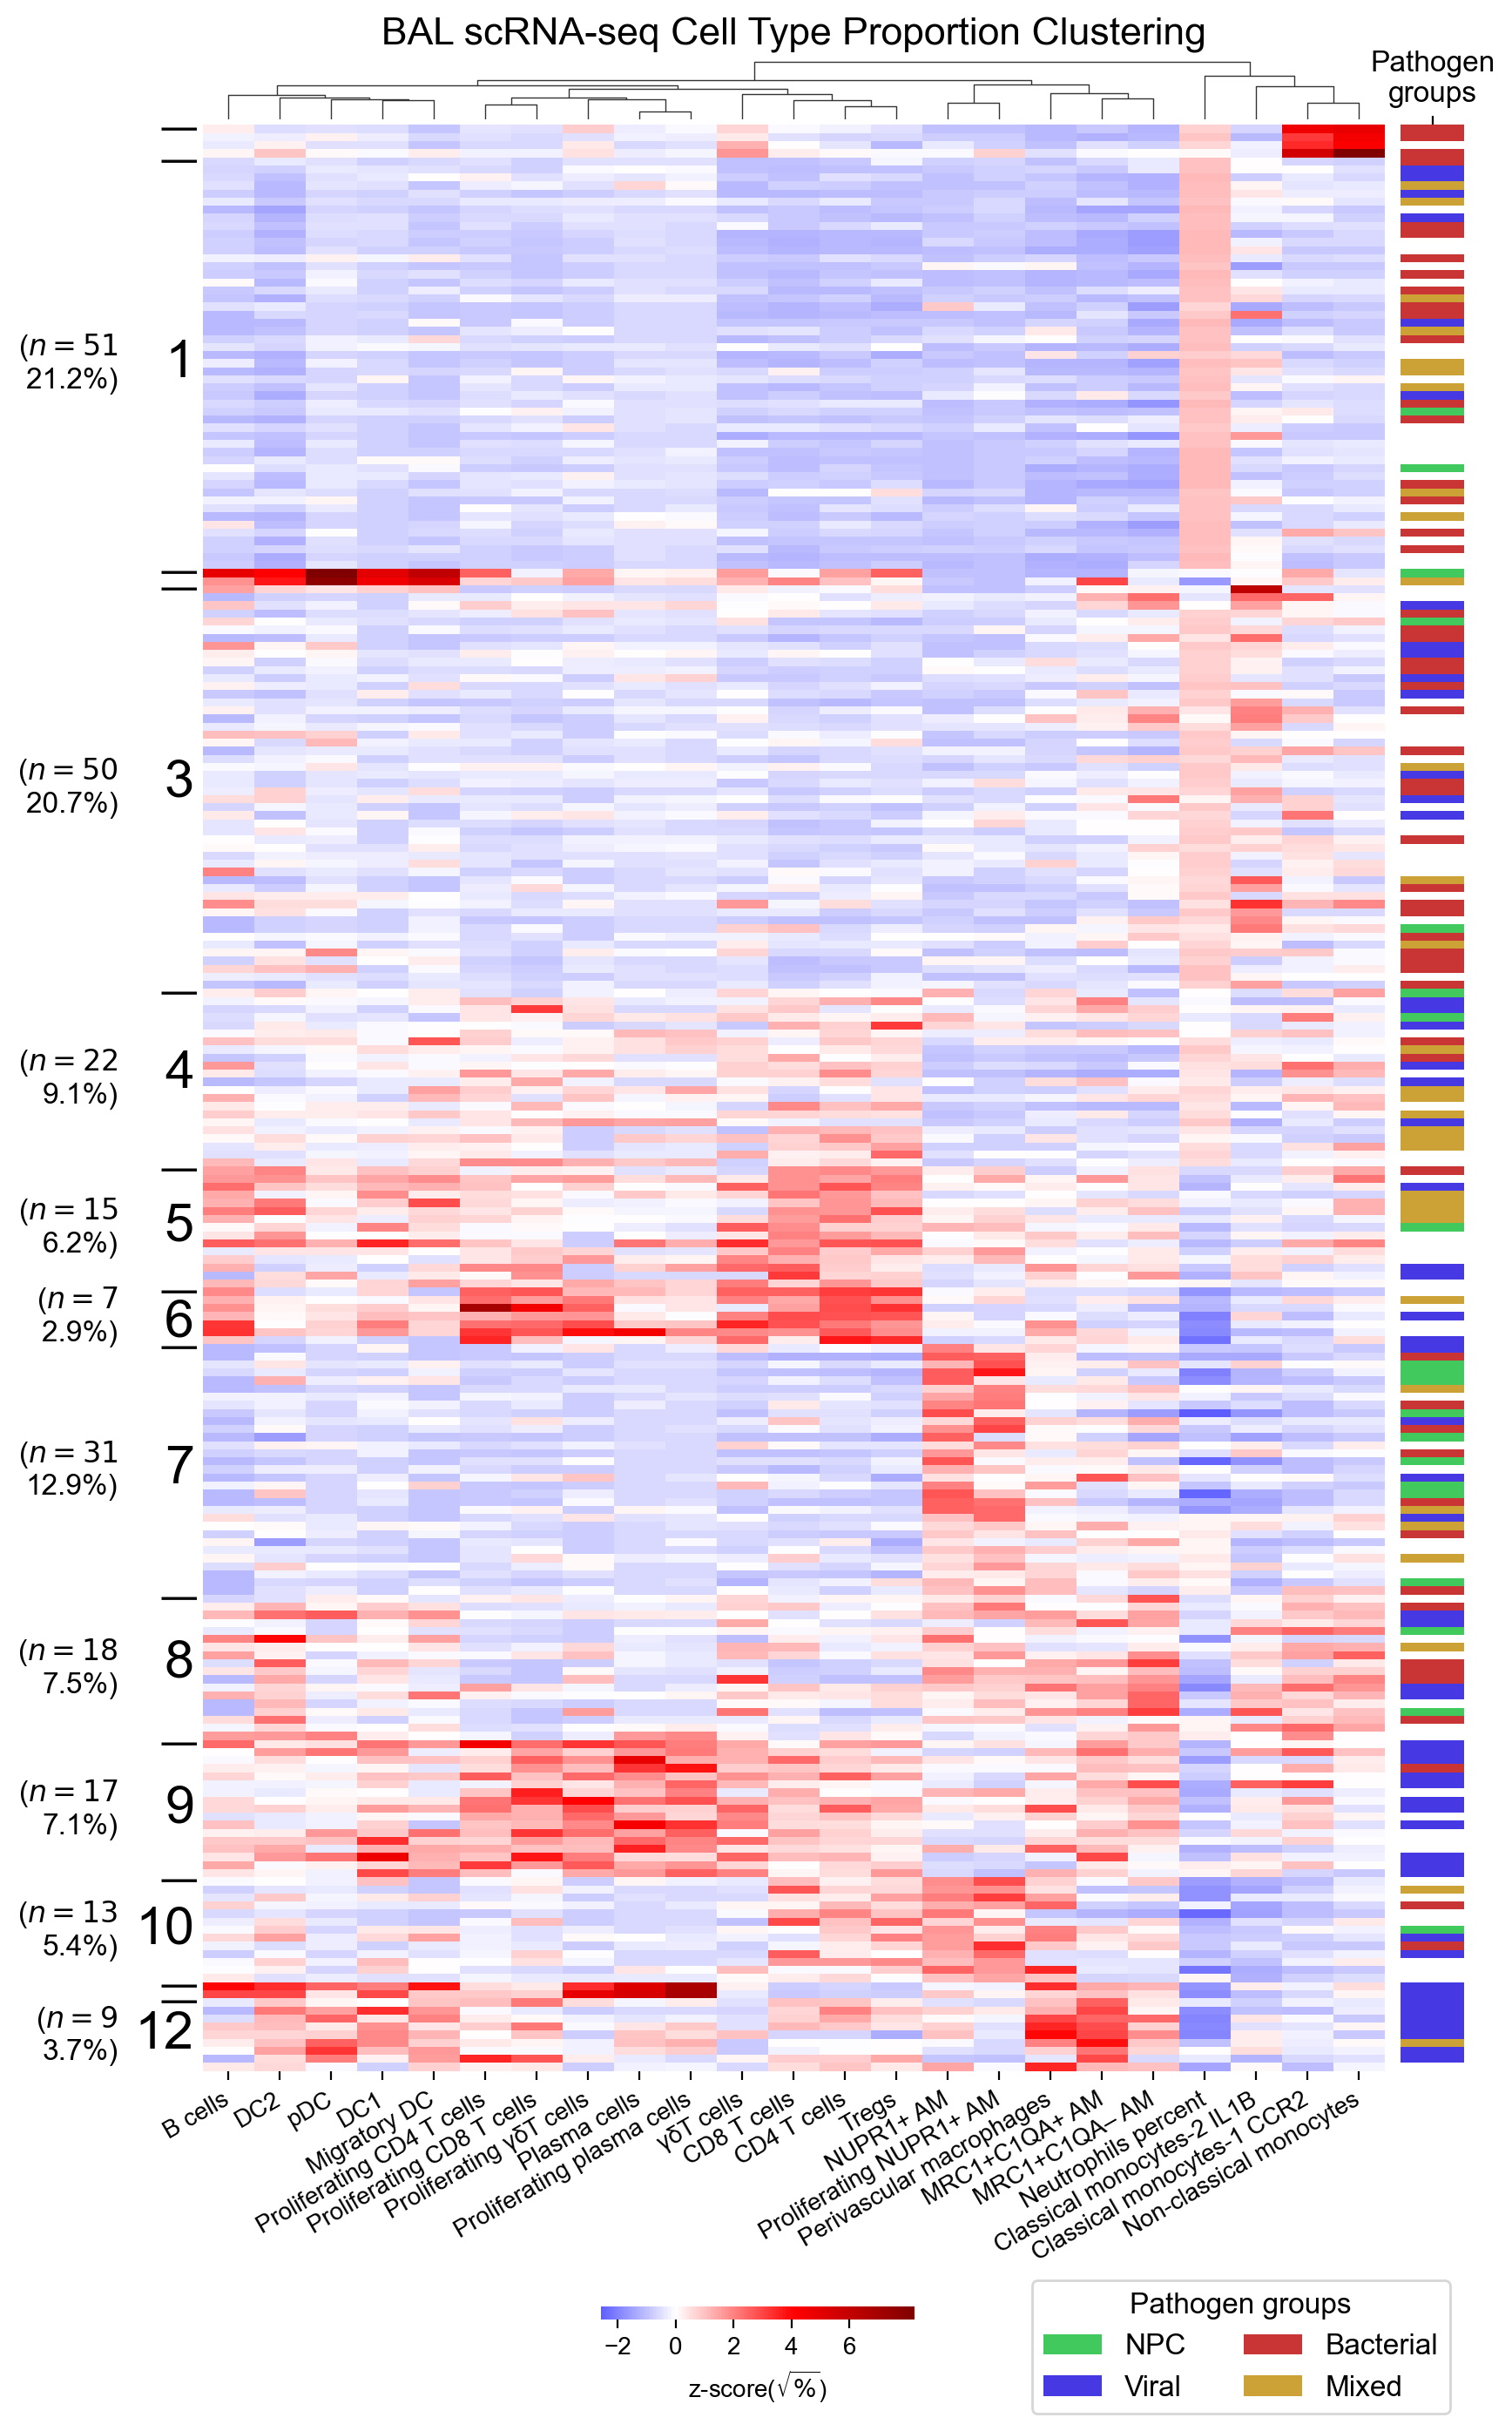

In [29]:
clustermap = sns.clustermap(
    flow_data_nn[cell_columns].loc[cluster_sorting],
    z_score=1,
    method='complete',
    metric='cityblock',
    cmap='seismic',
    row_cluster=False,
    figsize=(9, 15),
    colors_ratio=0.05,
    dendrogram_ratio=0.03,
    center=0,
    yticklabels=col_names,
    xticklabels=[CELL_TYPES_DISPLAY.get(name[15:], name[15:]) if name.startswith('LYMPHO_NNORMED:') else name for name in cell_columns],
    row_colors=col_colors,
    cbar_pos=(0, 0.02, 0.2, 0.01),
    cbar_kws=dict(
        label='z-score($\sqrt{\%}$)',
        orientation='horizontal',
        ticks=[-2, 0, 2, 4, 6]
    ),
)

clustermap.ax_row_dendrogram.set_visible(False)
_ = clustermap.ax_col_dendrogram.set_title('BAL scRNA-seq Cell Type Proportion Clustering', fontsize=16)
clustermap.ax_heatmap.set_yticklabels(
    clustermap.ax_heatmap.get_ymajorticklabels(),
    fontsize=16,
    rotation=90
)
clustermap.ax_heatmap.set_xticklabels(
    clustermap.ax_heatmap.get_xmajorticklabels(),
    fontsize=10,
    rotation=30,
    ha='right'
)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in clustermap.ax_heatmap.get_xticklabels():
    t.set_transform(t.get_transform() + trans)

clustermap.ax_heatmap.tick_params(
    axis='y',
    size=0,
    left=True,
    right=False,
    labelleft=True,
    labelright=False
)
clustermap.ax_row_colors.tick_params(
    axis='x',
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
)
clustermap.ax_row_colors.set_xticklabels(['Pathogen\ngroups'], size=12)
for t in clustermap.ax_row_colors.get_xticklabels():
    t.set_ha('center')
clustermap.ax_row_colors.legend(
    handles=[
        mpl.patches.Patch(fc=coarse_colors['NPC'], label='NPC'),
        mpl.patches.Patch(fc=coarse_colors['viral'], label='Viral'),
        mpl.patches.Patch(fc=coarse_colors['bacterial'], label='Bacterial'),
        mpl.patches.Patch(fc=coarse_colors['superinfection'], label='Mixed'),
    ],
    ncols=2,
    loc='upper right',
    bbox_to_anchor=(1, -0.1),
    title='Pathogen groups',
    fontsize=12,
    title_fontsize=12
)

for t in clustermap.ax_heatmap.get_yticklabels():
    t.set_va('bottom')
    if t.get_text() != '' and t.get_text() != '|':
        t.set_rotation(0)
        t.set_size(22)
        t.set_va('center')
        if t.get_text() == '6':
            t.set_transform(t.get_transform() + mpl.transforms.Affine2D().translate(0, -8))

i = 0
for cluster in sorted(full_df.clusters_final.unique()):
    n_samples = full_df.clusters_final.eq(cluster).sum()
    if n_samples < 5:
        i += n_samples
        continue
    pct_samples = n_samples / full_df.shape[0]
    clustermap.ax_heatmap.annotate(
        f'($n={n_samples}$\n{pct_samples * 100:.1f}%)',
        xy=(0, i + n_samples / 2),
        xytext=(-35, 0),
        xycoords='data',
        textcoords='offset points',
        ha='right',
        va='center',
        fontsize=12
    )
    i += n_samples

clustermap.figure.subplots_adjust(left=0.08, right=0.9, bottom=0.18, top=0.95)

p = clustermap.ax_row_colors.get_position()
w = p.x1 - p.x0
p_hm = clustermap.ax_heatmap.get_position()
p.x0 = p_hm.x1 + 0.01
p.x1 = p.x0 + w
clustermap.ax_row_colors.set_position(p)

clustermap.cax.set_position((0.4, 0.085, 0.2, 0.005))

clustermap.figure.savefig('10Hd_scrnaseq_clusters_coarse.pdf')

In [ ]:
def compute_hypergeometrics_for_df(
    df,
    column,
    values=None,
    cluster_column='clusters_final',
    add_prefix=True,
    filter_nas=True,
    filter_clusters=None,
    min_cluster_size=None,
    min_p_value=1e-5,
    min_count=3
):
    filter_clusters = filter_clusters if filter_clusters is not None else []
    nb_of_clusters = len(set(df[cluster_column]))
    clusters = [cl_ for cl_ in range(nb_of_clusters) if cl_ not in filter_clusters]
    if min_cluster_size is not None:
        clusters = [cl_ for cl_ in clusters if df[cluster_column].eq(cl_).sum() >= min_cluster_size]
    if filter_nas:
        df = df.copy()
        df = df[np.logical_not(df[column].isna())]
    if values is None:
        values = []
        for value, count in df[column].value_counts().items():
            if count >= min_count:
                values.append(value)
    results = np.zeros((len(clusters), len(values)))
    for val_nb, val in enumerate(values):
        for cluster_ind, cluster_nb in enumerate(clusters):
            cluster_count = (df[cluster_column] == cluster_nb).sum()
            if cluster_count == 0:
                results[cluster_ind, val_nb] = 1
                continue
            val_count = (df[column] == val).sum()
            val_within_cluster_count = (np.logical_and(df[column] == val, df[cluster_column] == cluster_nb)).sum()
            total = df.shape[0]
            cdf = scipy.stats.hypergeom.cdf(
                k=val_within_cluster_count - 1,
                M=total,
                n=val_count,
                N=cluster_count
            )
            results[cluster_ind, val_nb] = 1 - cdf
    results = np.maximum(results, min_p_value)
    if add_prefix:
        col_values = [f'{column}: {val}' for val in values]
    else:
        col_values = values
    result_df = pandas.DataFrame(data=results, columns=col_values, index=clusters)
    return result_df

In [31]:
def apply_fdr_to_df(
    df,
    alpha=0.1,
    method='fdr_bh'
):
    pvals = df.to_numpy().copy()
    flatten_pvals = pvals.flatten()
    _, q_vals, _, _ = multipletests(flatten_pvals, method=method, alpha=alpha)
    new_df = pandas.DataFrame(data=q_vals.reshape(df.shape), columns=df.columns, index=df.index)
    return new_df

In [ ]:
data_columns = [
    feature for feature in categorical_features
    if feature
    not in (
        'Flow_clusters', 'ScRNAseq_clusters', 'Healthy_vs_NPC_vs_Pathogen',
        'Global_cause_failure', 'Episode_is_cured',
    )
]

In [33]:
data_columns

['Binary_outcome',
 'CRRT_flag',
 'Discharge_disposition',
 'ECMO_flag',
 'Episode_category',
 'Episode_etiology',
 'Ethnicity',
 'Sex',
 'Hemodialysis_flag',
 'Immunocompromised_flag',
 'Norepinephrine_flag',
 'Pathogen_bacteria_detected',
 'Pathogen_fungi_detected',
 'Pathogen_resistance_detected',
 'Pathogen_virus_detected',
 'Race',
 'Smoking_status',
 'Tracheostomy_flag',
 'Pathogen_groups',
 'VAP_is_cured_d7']

In [34]:
full_df[full_df[data_columns] == 'NA'] = np.nan
full_df[full_df[data_columns] == '-1'] = np.nan
full_df[full_df[data_columns] == -1] = np.nan
full_df[full_df[data_columns] == 'discard'] = np.nan
full_df[full_df[data_columns] == 'Unknown or Not Reported'] = np.nan
full_df[full_df[data_columns] == 'Unknown Smoking Status'] = np.nan

In [35]:
all_pvals = [
    compute_hypergeometrics_for_df(
        df=full_df,
        column=data_col,
        min_cluster_size=5,
        min_p_value=1e-10,
        min_count=3
    )
    for data_col in data_columns
]

In [36]:
full_pvals = pandas.concat(all_pvals, axis=1)

Columns with significant associations in flow cytometry analysis

In [37]:
flow_columns = ['Binary_outcome: 1',
 'Binary_outcome: 0',
 'CRRT_flag: 1',
 'Discharge_disposition: Died',
 'Discharge_disposition: Home',
 'ECMO_flag: 0',
 'ECMO_flag: 1',
 'Episode_category: VAP',
 'Episode_category: CAP',
 'Episode_category: NPC',
 'Episode_etiology: Bacterial',
 'Episode_etiology: Viral',
 'Episode_etiology: Culture-negative',
 'Pathogen_bacteria_detected: False',
 'Pathogen_bacteria_detected: True',
 'Pathogen_fungi_detected: False',
 'Pathogen_virus_detected: False',
 'Pathogen_virus_detected: True',
 'Tracheostomy_flag: 1',
 'Pathogen_groups: Early SARS-CoV-2',
 'Pathogen_groups: Late SARS-CoV-2']

In [38]:
len(flow_columns)

21

In [39]:
full_pvals = full_pvals.drop(columns=['Pathogen_groups: NPC']).loc[:, flow_columns]

In [40]:
full_qvals = apply_fdr_to_df(full_pvals, alpha=0.05)

In [41]:
full_qvals

,Binary_outcome: 1,Binary_outcome: 0,CRRT_flag: 1,Discharge_disposition: Died,Discharge_disposition: Home,ECMO_flag: 0,ECMO_flag: 1,Episode_category: VAP,Episode_category: CAP,Episode_category: NPC,Episode_etiology: Bacterial,Episode_etiology: Viral,Episode_etiology: Culture-negative,Pathogen_bacteria_detected: False,Pathogen_bacteria_detected: True,Pathogen_fungi_detected: False,Pathogen_virus_detected: False,Pathogen_virus_detected: True,Tracheostomy_flag: 1,Pathogen_groups: Early SARS-CoV-2,Pathogen_groups: Late SARS-CoV-2
1,0.114959,1.000000,1.000000,0.127457,1.000000,1.000000,0.857214,0.481362,1.000000,1.000000,0.392517,1.000000,1.000000,1.000000,0.127457,1.000000,0.779239,1.000000,1.000000,1.000000,1.000000
3,0.025078,1.000000,1.000000,0.026764,1.000000,1.000000,0.127457,0.377533,1.000000,1.000000,0.377533,1.000000,0.524050,1.000000,0.495089,1.000000,0.050700,1.000000,1.000000,1.000000,1.000000
4,0.978418,1.000000,0.978418,0.969462,0.978418,1.000000,0.940941,0.937561,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.119677,1.000000,1.000000,1.000000
5,1.000000,0.377533,0.978418,1.000000,0.495089,1.000000,0.620623,0.476324,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.495089,0.365338,1.000000,1.000000
6,1.000000,0.243816,1.000000,1.000000,0.982216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.857214,1.000000,0.978418,1.000000,0.476324,1.000000,1.000000,0.524050,1.000000,0.978418
7,1.000000,0.978418,0.050809,1.000000,1.000000,0.978418,1.000000,1.000000,1.000000,0.025078,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.857214,1.000000,1.000000,1.000000,1.000000
8,0.937561,1.000000,1.000000,0.857214,1.000000,0.621983,1.000000,1.000000,0.982216,1.000000,0.978418,1.000000,0.156304,1.000000,1.000000,1.000000,0.744567,1.000000,1.000000,1.000000,1.000000
9,1.000000,0.621983,1.000000,1.000000,0.631507,0.377533,1.000000,1.000000,0.937561,1.000000,1.000000,0.025078,1.000000,0.156304,1.000000,0.744567,1.000000,0.124773,1.000000,0.025078,0.731568
10,1.000000,0.377533,0.476324,1.000000,1.000000,0.620623,1.000000,1.000000,1.000000,0.495089,1.000000,1.000000,1.000000,0.857214,1.000000,1.000000,1.000000,1.000000,0.495089,1.000000,0.701959
12,1.000000,0.094563,1.000000,1.000000,0.026764,0.476324,1.000000,1.000000,0.026764,1.000000,1.000000,0.029273,1.000000,0.073749,1.000000,1.000000,1.000000,0.126333,1.000000,0.018670,1.000000


In [42]:
full_qvals.shape, full_qvals.values.min(), full_qvals.min().idxmin()

((10, 21), 0.018669839567128088, 'Pathogen_groups: Early SARS-CoV-2')

In [43]:
significant_cols = []

for col_name, col_min in full_qvals.min(axis=0).items():
    if col_min < 0.05:
        significant_cols.append(col_name)

In [44]:
significant_full_qvals = full_qvals[significant_cols]

In [45]:
def get_stars_from_pvalue(pvalue):
    result = ''
    if pvalue < 0.1:
        result += '*'
    if pvalue < 0.01:
        result += '*'
    if pvalue < 0.001:
        result += '*'
    return result

In [46]:
clustering_sorting_names = [
    '1. Neutrophil+',
    '3. Neutrophil+ Monocyte',
    '4. Neutrophil+ T cell',
    '5. T cell+',
    '6. Lymphocyte',
    '7. Mature macrophage+',
    '8. Macrophage+',
    '9. Immature macrophage+ Lymphocyte',
    '10. Mature macrophage+ T cell',
    '12. Immature macrophage+ DC',
]

In [47]:
significant_full_qvals.columns.tolist()

['Binary_outcome: 1',
 'Discharge_disposition: Died',
 'Discharge_disposition: Home',
 'Episode_category: CAP',
 'Episode_category: NPC',
 'Episode_etiology: Viral',
 'Pathogen_groups: Early SARS-CoV-2']

In [ ]:
to_show = {
    'Pathogen_groups: Early SARS-CoV-2': 'Early SARS-CoV-2',
    'Episode_etiology: Viral': 'Adjudicated pathogen: viral',
    'Episode_category: CAP': 'CAP',
    'Episode_category: NPC': 'NPC',
    'Discharge_disposition: Home': 'Discharge disposition: Home',
    'Discharge_disposition: Died': 'Discharge disposition: Died',
    'Binary_outcome: 1': 'Died',
}

In [ ]:
cluster_order = [
    0, 1, 2, 3, 4, 7, 9, 6, 8, 5
]

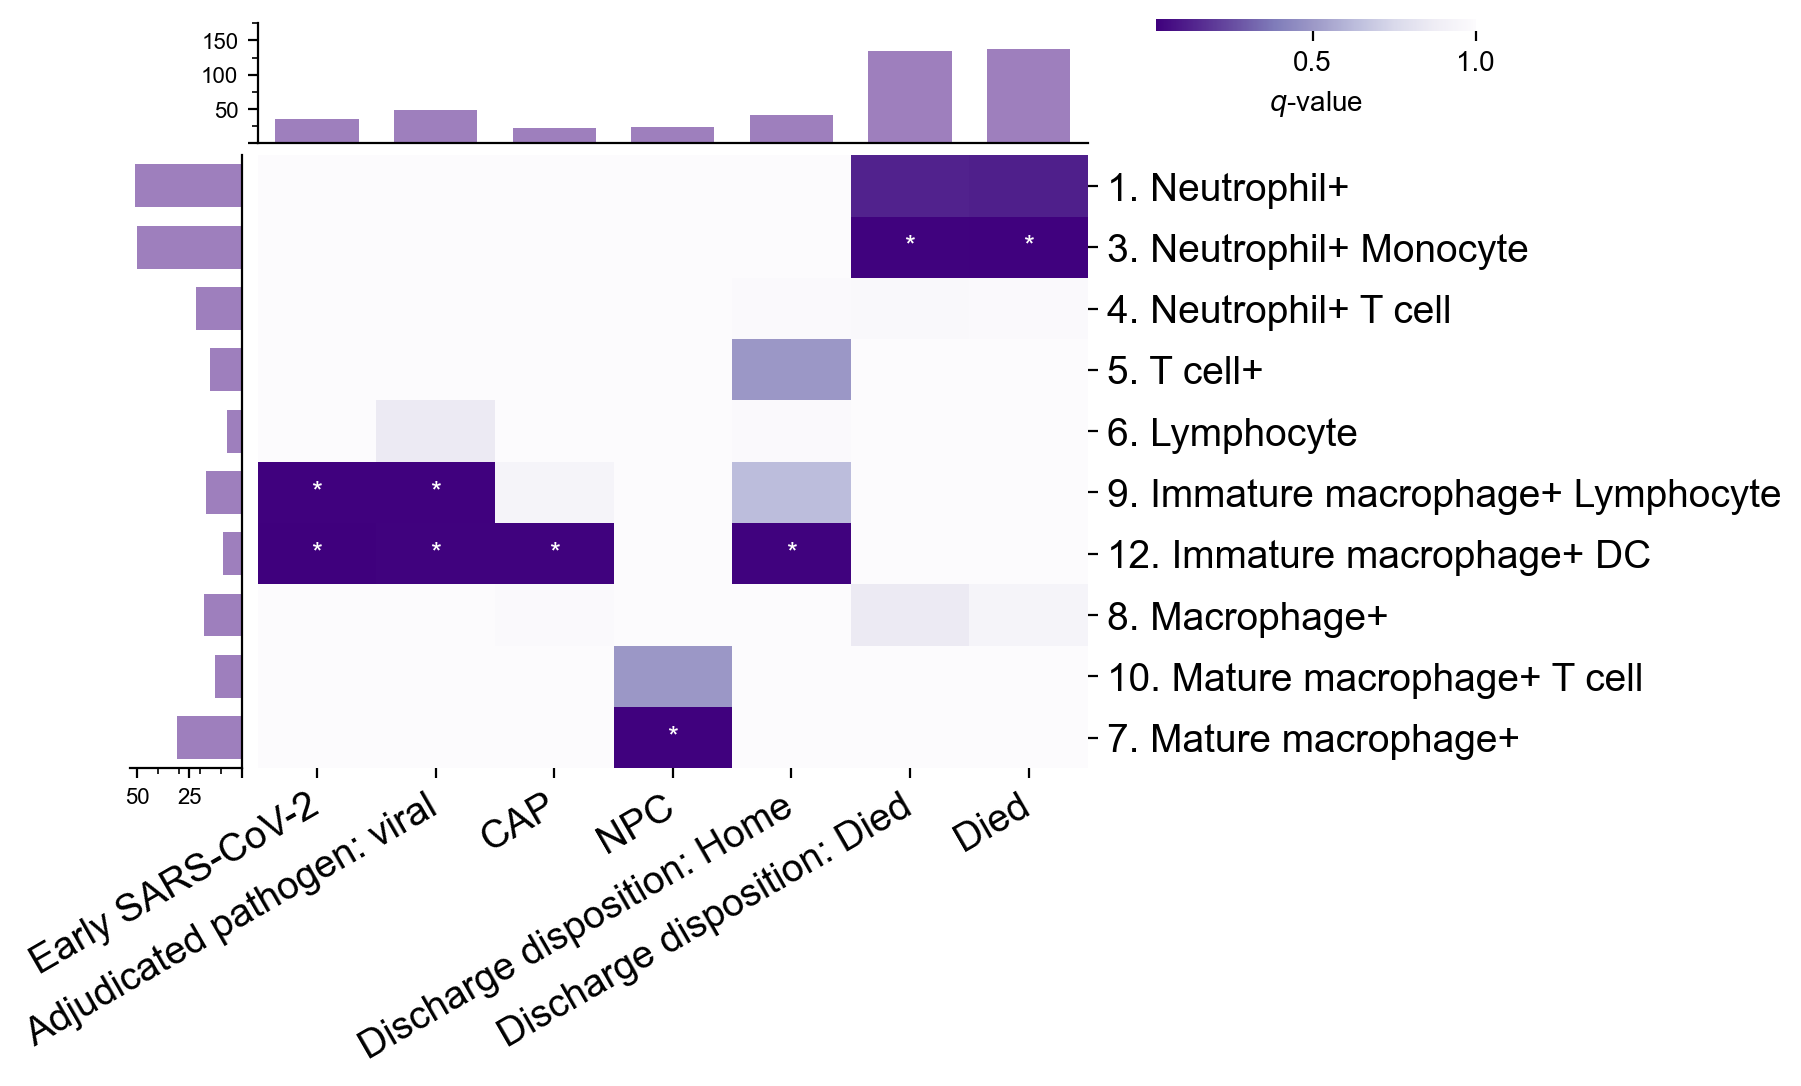

In [50]:
significant_full_qvals_text = significant_full_qvals.copy()
significant_full_qvals_text = significant_full_qvals_text.applymap(get_stars_from_pvalue)

cg = sns.clustermap(
    significant_full_qvals.loc[:, list(to_show.keys())].iloc[cluster_order],
    figsize=(8, 6),
    row_cluster=False,
    col_cluster=False,
    cmap='Purples_r',
    cbar_pos=(0.71, 0.95, 0.2, 0.01),
    annot=significant_full_qvals_text.loc[:, to_show.keys()].iloc[cluster_order],
    fmt='',
    yticklabels=np.array(clustering_sorting_names)[cluster_order],
    xticklabels=list(to_show.values()),
    cbar_kws=dict(
        orientation='horizontal',
        label='$q$-value'
    )
)

# cg.ax_heatmap.set_title(
#     'Hypergeometric FDR q-value for clinical feature enrichment\n'
#     'in Flow cell type abundance based clustering',
#     fontsize=12
# )
cg.ax_col_dendrogram.set_visible(False)
cg.ax_row_dendrogram.set_visible(False)
# cg.ax_heatmap.set_ylabel('Flow cluster')

cg.ax_heatmap.set_xticklabels(
    cg.ax_heatmap.get_xmajorticklabels(),
    fontsize=14,
    rotation=30,
    ha='right'
)
trans = mpl.transforms.Affine2D().translate(8, 0)
for t in cg.ax_heatmap.get_xticklabels():
    t.set_transform(t.get_transform() + trans)

cg.ax_heatmap.tick_params(labelsize=14)

p = cg.ax_heatmap.get_position()
cg.ax_col_marginal = cg.figure.add_axes([p.x0, p.y1 + 0.01, p.x1 - p.x0, 0.1], sharex=cg.ax_heatmap)
cg.ax_col_marginal.get_xaxis().set_visible(False)

label_fracs = []
for col_name in to_show.keys():
    col, value = col_name.split(': ')
    frac = full_df[col].eq(value).sum() # / full_df.shape[0]
    label_fracs.append(frac)

label_fracs = np.array(label_fracs)
cg.ax_col_marginal.bar(
    np.arange(len(to_show)) + 0.5,
    label_fracs,
    width=0.7,
    color=mpl._cm._Purples_data[-1],
    alpha=0.5
)
cg.ax_col_marginal.spines[['top', 'right']].set_visible(False)
cg.ax_col_marginal.tick_params(labelsize=8)#, left=False, labelleft=False, right=True, labelright=True)
cg.ax_col_marginal.set_yticks([0, 50, 100, 150], labels=['', '50', '100', '150'])
cg.ax_col_marginal.set_yticks([25, 75, 125, 175], minor=True)

cg.ax_row_marginal = cg.figure.add_axes([p.x0 - 0.08, p.y0, 0.07, p.y1 - p.y0], sharey=cg.ax_heatmap)
cg.ax_row_marginal.invert_xaxis()
cg.ax_row_marginal.get_yaxis().set_visible(False)
cg.ax_row_marginal.barh(
    np.arange(significant_full_qvals.shape[0]) + 0.5,
    full_df.ScRNAseq_clusters[
        full_df.ScRNAseq_clusters.isin(significant_full_qvals.index.astype(str))
    ].astype(str).astype(int).value_counts().sort_index().iloc[cluster_order], # / full_df.shape[0],
    height=0.7,
    color=mpl._cm._Purples_data[-1],
    alpha=0.5
)
cg.ax_row_marginal.spines[['top', 'left']].set_visible(False)
cg.ax_row_marginal.tick_params(labelsize=8)#, left=False, labelleft=False, right=True, labelright=True)
cg.ax_row_marginal.set_xticks([0, 25, 50], labels=['', '25', '50'])
cg.ax_row_marginal.set_xticks([10, 20, 30, 40], minor=True)

cg.savefig('10Hd_cluster_categorical_enr_main.pdf')

In [55]:
def compute_t_test_for_df(
    df,
    column,
    cluster_column='clusters_final',
    add_prefix=True,
    filter_nas=True,
    filter_clusters=None,
    min_cluster_size=None,
    min_p_value=1e-5,
    alternative='less',
):
    filter_clusters = filter_clusters if filter_clusters is not None else []
    nb_of_clusters = len(set(df[cluster_column]))
    clusters = [cl_ for cl_ in range(nb_of_clusters) if cl_ not in filter_clusters]
    if min_cluster_size is not None:
        clusters = [cl_ for cl_ in clusters if df[cluster_column].eq(cl_).sum() >= min_cluster_size]
    if filter_nas:
        df = df.copy()
        df = df[np.logical_not(df[column].isna())]
    results = np.zeros((len(clusters), 1))
    for cluster_ind, cluster_nb in enumerate(clusters):
        # print(column, cluster_nb)
        if sum(df[cluster_column] == cluster_nb) == 0:
            print(cluster_column, cluster_nb, column)
            results[cluster_ind] = 1
            continue
        cluster_vals = df[column][df[cluster_column] == cluster_nb]
        outside_cluster_vals = df[column][df[cluster_column] != cluster_nb]
        results[cluster_ind] = scipy.stats.ttest_ind(
            cluster_vals,
            outside_cluster_vals,
            equal_var=False,
            alternative=alternative,
        ).pvalue
    results = np.maximum(results, min_p_value)
    result_df = pandas.DataFrame(data=results, columns=[column], index=clusters)
    return result_df

In [56]:
def compute_anova_test_for_df(
    df,
    column,
    cluster_column='clusters_final',
    add_prefix=True,
    filter_nas=True,
    filter_clusters=None,
    min_cluster_size=None,
    min_p_value=1e-5,
    alternative='less',
):
    filter_clusters = filter_clusters if filter_clusters is not None else []
    nb_of_clusters = len(set(df[cluster_column]))
    clusters = [cl_ for cl_ in range(nb_of_clusters) if cl_ not in filter_clusters]
    if min_cluster_size is not None:
        clusters = [cl_ for cl_ in clusters if df[cluster_column].eq(cl_).sum() >= min_cluster_size]
    if filter_nas:
        df = df.copy()
        df = df[np.logical_not(df[column].isna())]
    results = np.zeros((len(clusters), 1))
    for cluster_ind, cluster_nb in enumerate(clusters):
        # print(column, cluster_ind)
        if sum(df[cluster_column] == cluster_nb) == 0:
            print(cluster_column, cluster_nb, column)
            results[cluster_ind] = 1
            continue
        cluster_vals = df[column][df[cluster_column] == cluster_nb]
        outside_cluster_vals = df[column][df[cluster_column] != cluster_nb]
        results[cluster_ind] = scipy.stats.f_oneway(
            cluster_vals,
            outside_cluster_vals,
            #equal_var=False,
            #alternative=alternative,
        ).pvalue
    results = np.maximum(results, min_p_value)
    result_df = pandas.DataFrame(data=results, columns=[column], index=clusters)
    return result_df

In [57]:
numericals.columns

Index(['Age', 'BMI', 'SOFA_score', 'days_on_ventilator', 'GSC_score',
       'PaO2FIO2_ratio', 'Mean_arterial_pressure', 'Bicarbonate', 'ABG_pH',
       'ABG_PaCO2', 'Urine_output', 'Heart_rate', 'Respiratory_rate',
       'Creatinine', 'Albumin', 'Bilirubin', 'Hemoglobin', 'Platelets',
       'Temperature', 'Driving_pressure', 'Minute_Ventilation', 'Neutrophils',
       'Lymphocytes', 'Procalcitonin_ff', 'Lactic_acid', 'D_dimer_ff',
       'LDH_ff', 'Cumulative_vent_changes', 'BAL_pct_neutrophils',
       'BAL_pct_lymphocytes', 'BAL_amylase', 'Episode_duration',
       'days_of_icu_abx_until_today',
       'cumulative_icu_steroid_dose_until_today', 'sequencing_depth',
       'sequencing_saturation', 'frac_reads_in_cells', 'viability'],
      dtype='object')

In [58]:
nc_all_pvals = [
    compute_t_test_for_df(
        df=full_df,
        column=data_col,
        min_cluster_size=5,
        min_p_value=1e-10
    )
    for data_col in numericals.columns
]

In [59]:
nc_all_anova_pvals = [
    compute_anova_test_for_df(
        df=full_df,
        column=data_col,
        min_cluster_size=5,
        filter_clusters=[2, 11],
    )
    for data_col in numericals.columns
]

In [60]:
full_nc_pvals = pandas.concat(nc_all_pvals, axis=1)

In [61]:
full_nc_anova_pvals = pandas.concat(nc_all_anova_pvals, axis=1)

In [62]:
full_nc_pvals.fillna(0.5, inplace=True)

In [63]:
full_nc_pvals_ts = pandas.DataFrame(
    2 - 2 * np.maximum(full_nc_pvals.values, 1 - full_nc_pvals.values),
    columns=full_nc_pvals.columns,
    index=full_nc_pvals.index,
)

In [64]:
full_nc_pvals['BAL_pct_neutrophils']

1     1.000000
3     1.000000
4     0.937846
5     0.001557
6     0.002132
7     0.000902
8     0.011468
9     0.007494
10    0.000801
12    0.065793
Name: BAL_pct_neutrophils, dtype: float64

In [65]:
full_qvals_nc_ts = apply_fdr_to_df(full_nc_pvals_ts, alpha=0.05)

In [66]:
full_qvals_nc_anova = apply_fdr_to_df(full_nc_anova_pvals, alpha=0.05)

In [67]:
significant_cols_nc = []

for col_name, col_min in full_qvals_nc_ts.min(axis=0).items():
    if col_min < 0.05:
        significant_cols_nc.append(col_name)

In [68]:
significant_cols_anova_nc = []

for col_name, col_min in full_qvals_nc_anova.min(axis=0).items():
    if col_min < 0.05:
        significant_cols_anova_nc.append(col_name)

In [69]:
full_qvals_nc_ts = full_qvals_nc_ts[significant_cols_nc]

In [70]:
full_qvals_nc_anova = full_qvals_nc_anova[significant_cols_anova_nc]

In [71]:
significant_cols_anova_nc

['Bicarbonate',
 'Hemoglobin',
 'Driving_pressure',
 'Lactic_acid',
 'D_dimer_ff',
 'BAL_pct_neutrophils',
 'BAL_pct_lymphocytes',
 'sequencing_saturation',
 'frac_reads_in_cells',
 'viability']

In [72]:
colored = np.sign(-2 * full_nc_pvals[significant_cols_nc] + 1) * (np.log(full_qvals_nc_ts + 1e-6))

In [73]:
text = full_qvals_nc_ts.applymap(get_stars_from_pvalue)
#text[full_qvals_nc_ts.applymap(lambda x: float(x)) > 0.05] = ''

In [74]:
PRETTY_NUM_NAMES = {
    'BAL_pct_lymphocytes': 'BAL lymphocytes (%)',
    'Minute_Ventilation': 'Minute ventilation',
    'BAL_pct_neutrophils': 'BAL neutrophils (%)',
    'cumulative_icu_steroid_dose_until_today': 'ICU steroid dose to date',
    'PaO2FIO2_ratio': r'P$_{\mathrm{a}}$O$_2$/F$_{\mathrm{i}}$O$_2$',
    'days_on_ventilator': 'Days on ventilator',
    'D_dimer_ff': 'D-dimer',
    'LDH_ff': 'LDH',
    'Procalcitonin_ff': 'Procalcitonin',
    'days_of_icu_abx_until_today': 'ICU antibiotic days to date',
    'ABG_PaCO2': r'P$_{\mathrm{a}}$CO$_2$',
    'frac_reads_in_cells': 'Fraction of reads in cells',
    'viability': 'Cell viability in sample',
    'sequencing_saturation': 'Sequencing saturation'
}
def pretty_num(name: str) -> str:
    name = PRETTY_NUM_NAMES.get(name, name)
    if '$' in name:
        idx = name.index('$')
        name = name[:idx].replace('_', ' ') + name[idx:]
    else:
        name = name.replace('_', ' ')
    return name

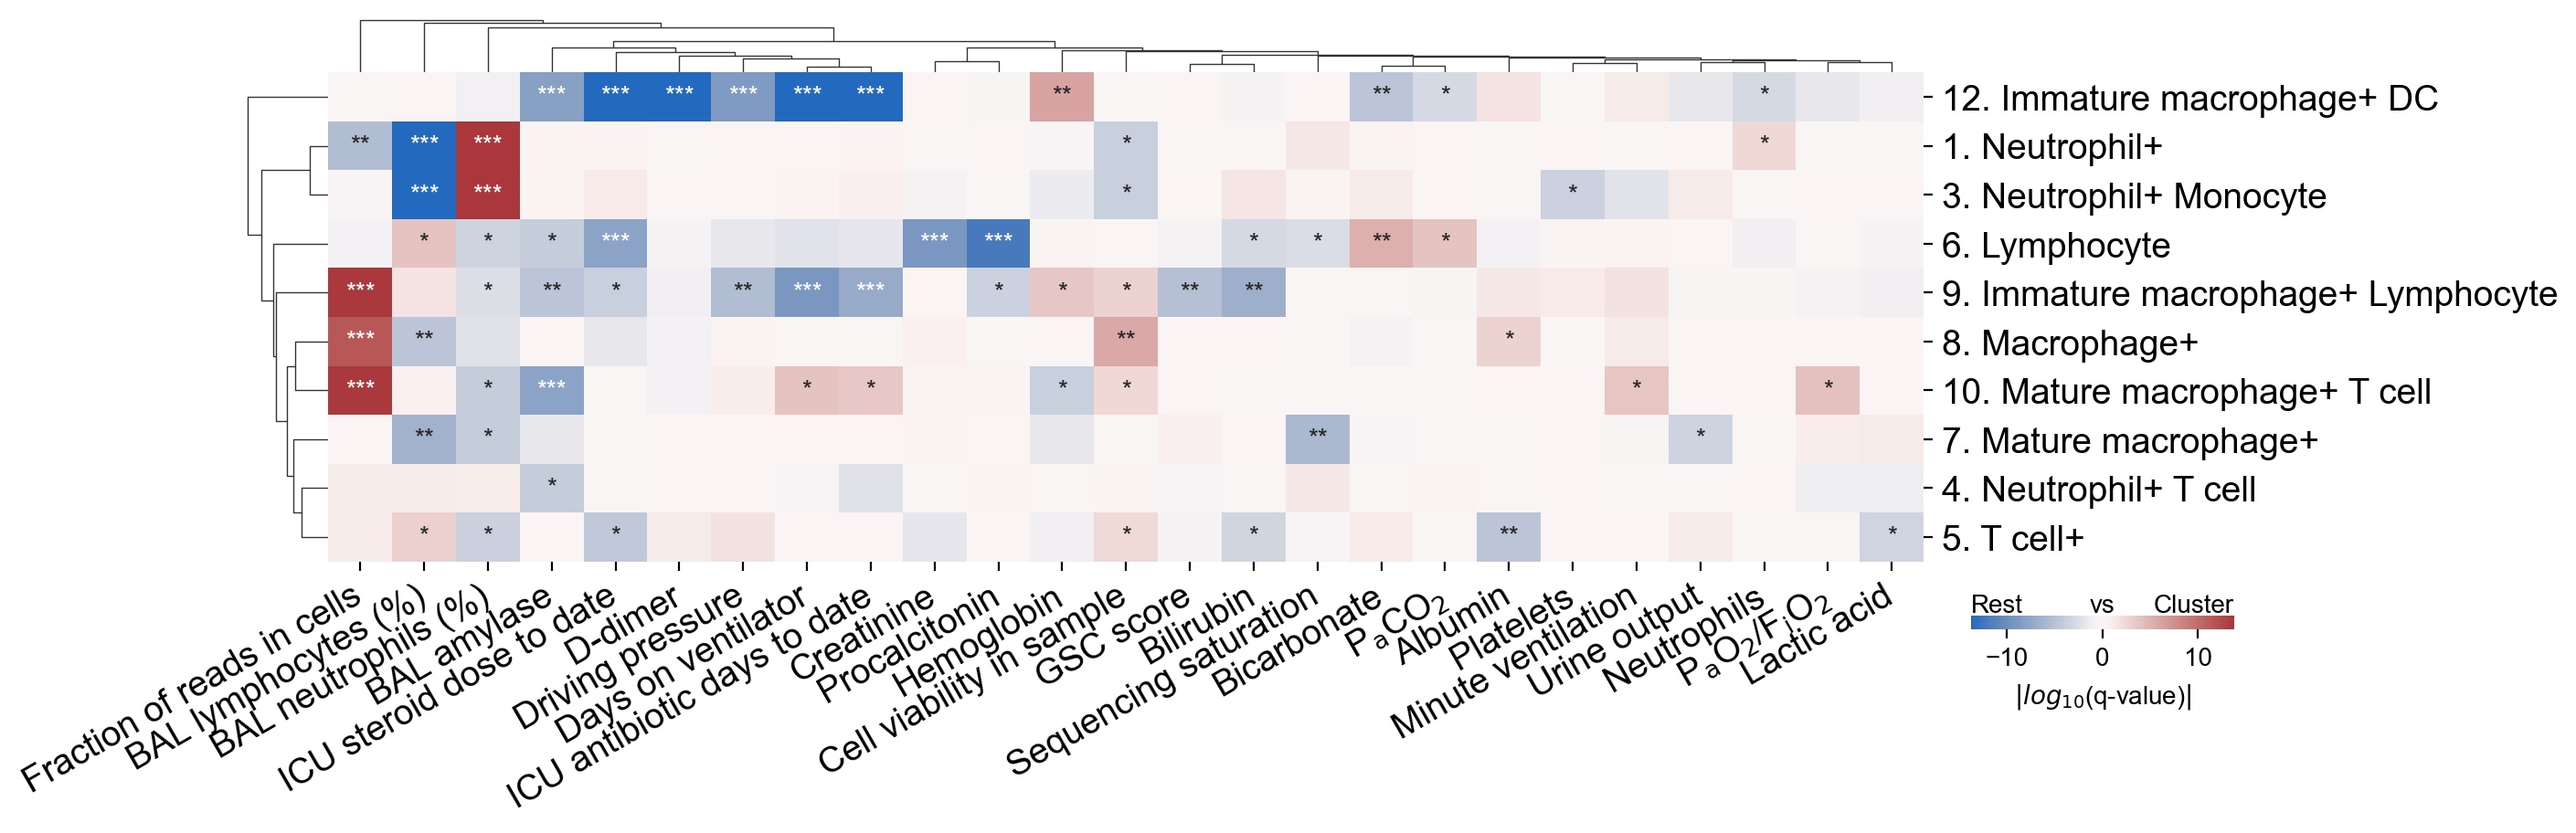

In [75]:
cg = sns.clustermap(
    colored,
    center=0,
    annot=text,
    # yticklabels=clustering_sorting_names,
    fmt='',
    cmap='vlag',
    yticklabels=clustering_sorting_names,
    figsize=(12, 5),
    cbar_pos=(0.8, 0.3, 0.12, 0.015),
    cbar_kws=dict(
        orientation='horizontal',
        label='$|log_{10}$(q-value)$|$'
    ),
    dendrogram_ratio=(0.05, 0.1),
    xticklabels=[pretty_num(s) for s in colored.columns]
)
cg.ax_cbar.annotate('Rest', (0, 1.3), xycoords='axes fraction', ha='left')
cg.ax_cbar.annotate('Cluster', (1, 1.3), xycoords='axes fraction', ha='right')
cg.ax_cbar.annotate('vs', (0.5, 1.3), xycoords='axes fraction', ha='center')
cg.ax_heatmap.set_ylabel('')

cg.ax_heatmap.set_yticklabels(
    cg.ax_heatmap.get_yticklabels(),
    fontsize=14,
)
cg.ax_heatmap.set_xticklabels(
    cg.ax_heatmap.get_xticklabels(),
    fontsize=14,
    rotation=30,
    ha='right'
)
trans = mpl.transforms.Affine2D().translate(8, 0)
for t in cg.ax_heatmap.get_xticklabels():
    t.set_transform(t.get_transform() + trans)

cg.savefig('10Hd_cluster_numerical_assoc.pdf')

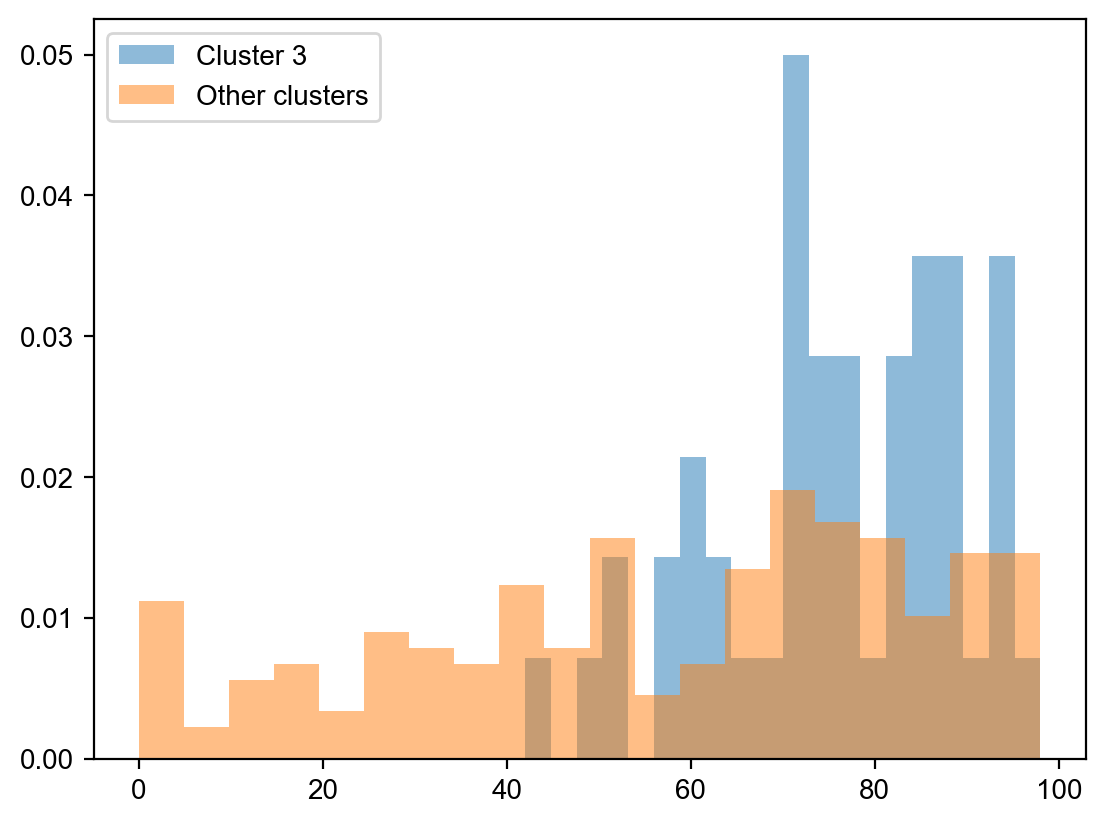

In [76]:
plt.hist(
    full_df['BAL_pct_neutrophils'][full_df['clusters_final'] == 3],
    bins=20,
    alpha=0.5,
    density=True,
    label='Cluster 3'
)
plt.hist(
    full_df['BAL_pct_neutrophils'][full_df['clusters_final'] != 3],
    bins=20,
    alpha=0.5,
    density=True,
    label='Other clusters'
)
plt.legend();

## Mean cluster profile

In [77]:
avg_cluster_profile_pct = full_df.groupby('clusters_final')[cell_columns].mean()
avg_cluster_profile = avg_cluster_profile_pct ** 0.5
avg_cluster_profile[:] = sk_preprocessing.StandardScaler().fit_transform(avg_cluster_profile)

In [78]:
avg_cluster_profile_pct = avg_cluster_profile_pct.applymap(lambda x: f'{x * 100:.1f}%')

In [79]:
colnames = full_df.groupby('clusters_final').size().lt(5).reset_index()
colnames.clusters_final = colnames.clusters_final.astype(str)
colnames.loc[colnames[0], 'clusters_final'] += '*'

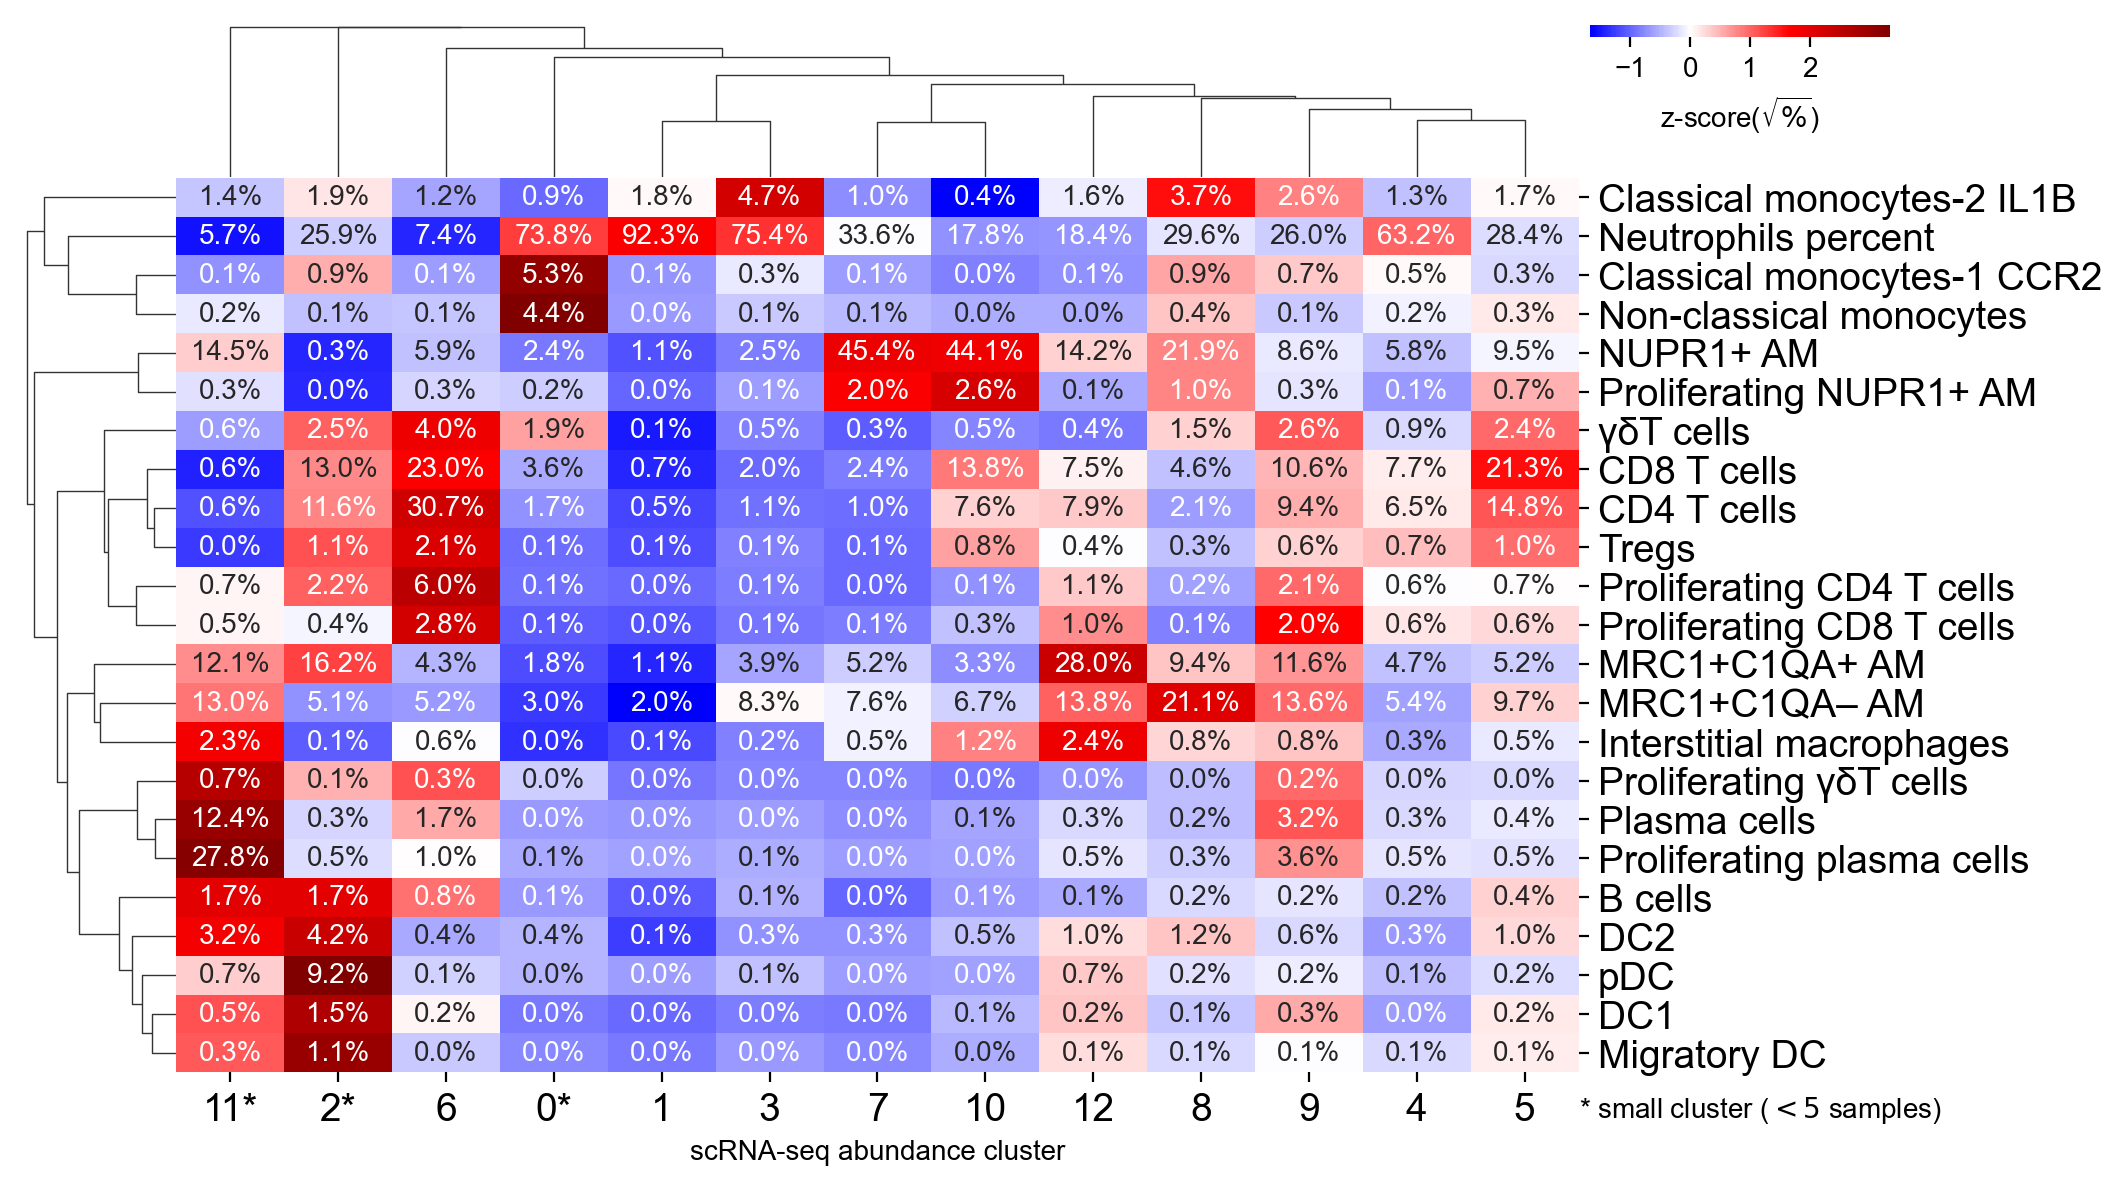

In [ ]:
cg = sns.clustermap(
    avg_cluster_profile.T,
    cmap='seismic',
    center=0,
    annot=avg_cluster_profile_pct.T,
    fmt='',
    cbar_pos=(0.8, 0.96, 0.15, 0.01),
    cbar_kws=dict(
        label=r'z-score($\sqrt{\%}$)',
        orientation='horizontal',
        ticks=[-1, 0, 1, 2]
    ),
    figsize=(10, 6),
    dendrogram_ratio=(0.1, 0.15),
    yticklabels=[
        CELL_TYPES_DISPLAY.get(name[15:], name[15:]).replace('Perivascular', 'Interstitial')
            if name.startswith('LYMPHO_NNORMED:')
            else name
        for name
        in cell_columns],
    xticklabels=colnames.clusters_final
)
cg.ax_heatmap.tick_params(labelsize=14)

cg.ax_heatmap.annotate('* small cluster ($<5$ samples)', (1, -0.05), xycoords='axes fraction')
cg.ax_heatmap.set_xlabel('scRNA-seq abundance cluster')
cg.savefig('10Hd_scrnaseq_cluster_profile.pdf')

In [83]:
avg_cluster_profile_pct = full_df.groupby('clusters_final')[cell_columns].mean()
avg_cluster_profile = avg_cluster_profile_pct ** 0.5
avg_cluster_profile[:] = sk_preprocessing.StandardScaler().fit_transform(avg_cluster_profile)

In [84]:
to_keep = full_df.groupby('clusters_final').size().ge(5).values
avg_cluster_profile = avg_cluster_profile.loc[to_keep]
avg_cluster_profile_pct = avg_cluster_profile_pct.loc[to_keep]

In [85]:
avg_cluster_profile_pct = avg_cluster_profile_pct.applymap(lambda x: f'{x * 100:.1f}%')

In [86]:
cell_type_order = [
    'Neutrophils percent',
    'CD8 T cells',
    'CD4 T cells',
    'gdT cells',
    'Tregs',

    'Proliferating CD8 T cells',
    'Proliferating CD4 T cells',
    'Proliferating gdT cells',

    'B cells',
    'Plasma cells',
    'Proliferating plasma cells',

    'pDC',
    'Migratory DC',
    'DC1',
    'DC2',

    'Perivascular macrophages',
    'Non-classical monocytes',
    'Classical monocytes-1 CCR2',
    'Classical monocytes-2 IL1B',

    'MRC1+C1QA-',
    'MRC1+C1QA+',
    'Proliferating NUPR1+ Macs',
    'NUPR1+ Macs',
]

In [87]:
avg_cluster_profile_pct.columns = [name[15:] if name.startswith('LYMPHO_NNORMED:') else name for name in avg_cluster_profile_pct.columns]
avg_cluster_profile.columns = [name[15:] if name.startswith('LYMPHO_NNORMED:') else name for name in avg_cluster_profile.columns]

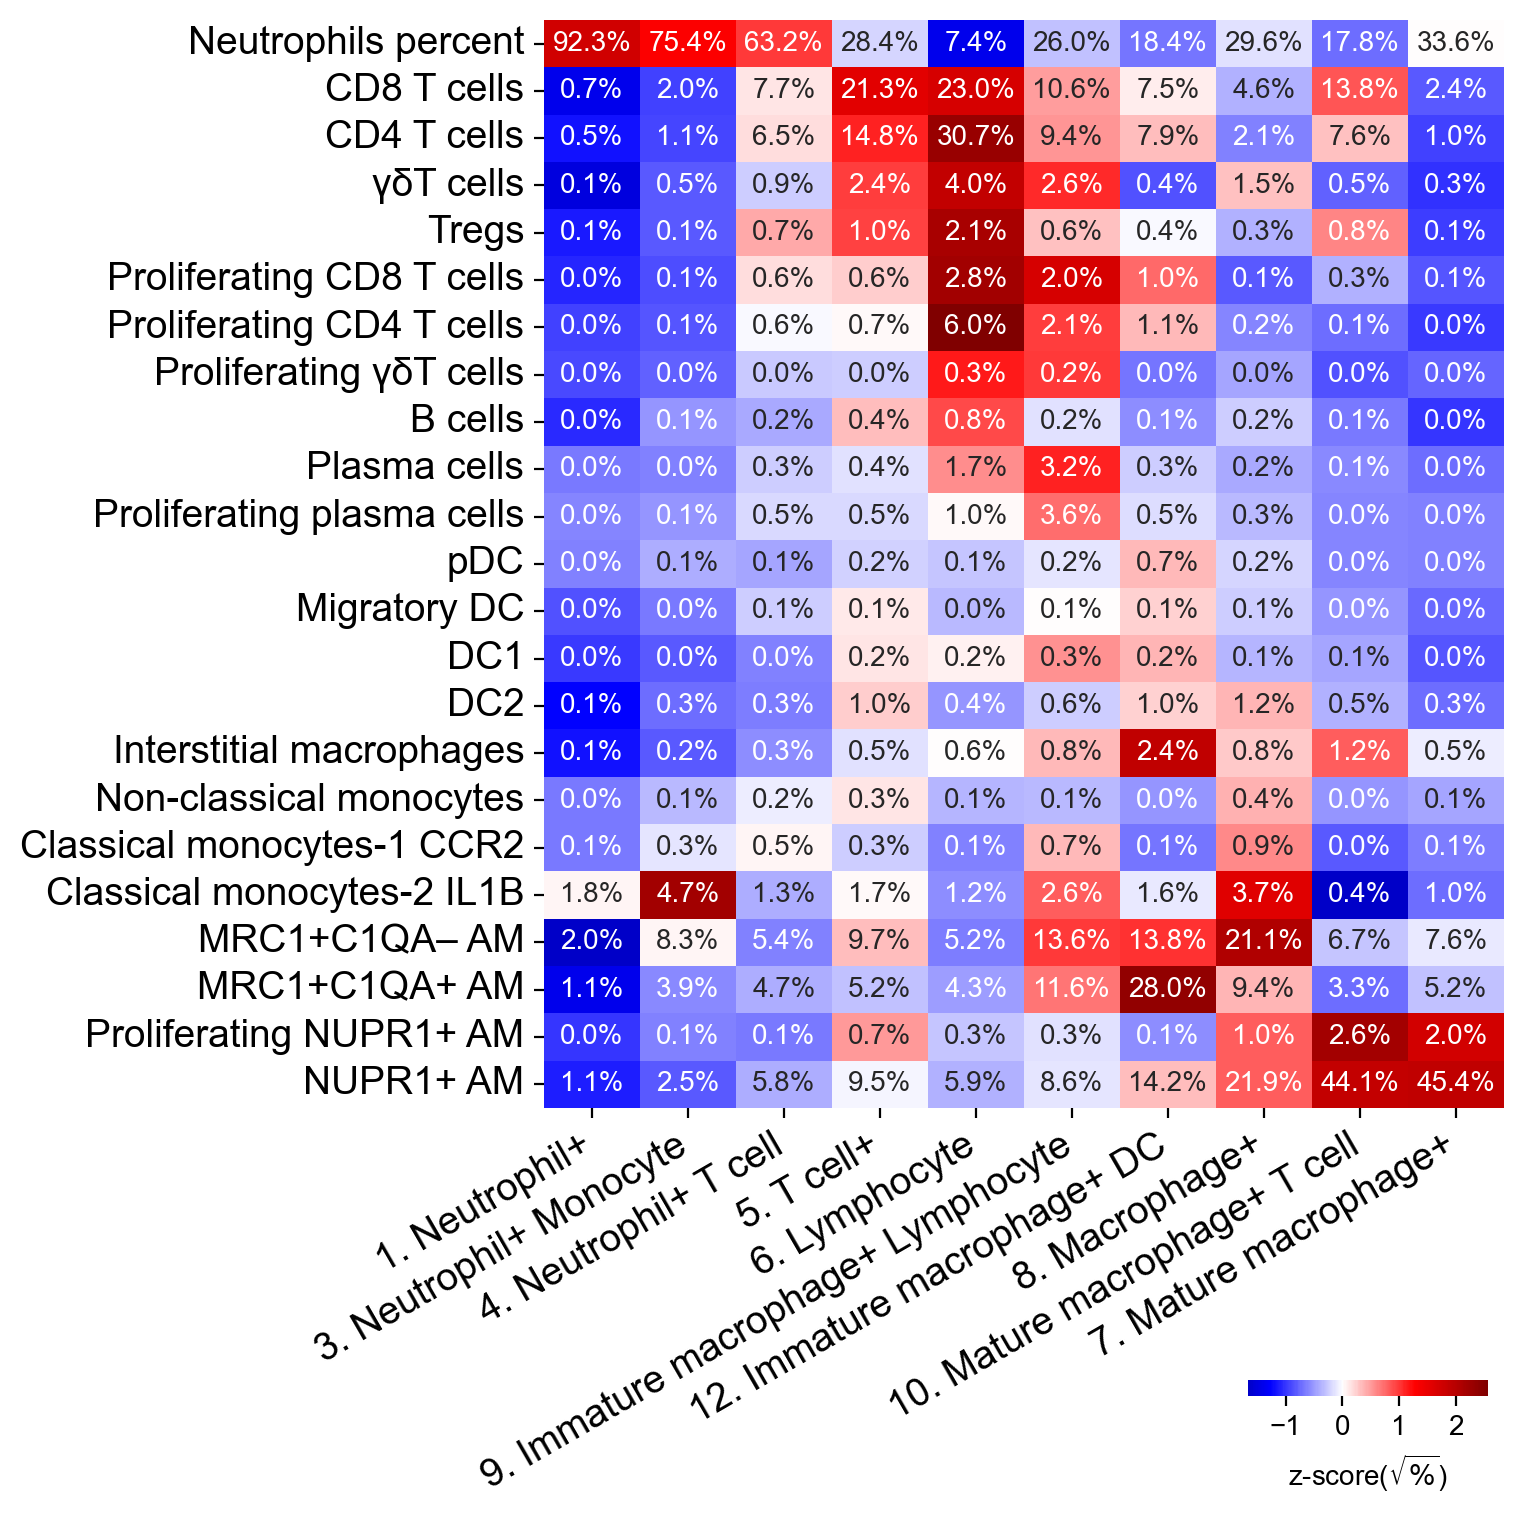

In [88]:
fig, ax = plt.subplots(figsize=(8, 8))

cbar_ax = fig.add_axes((0.82, 0.12, 0.15, 0.01))

sns.heatmap(
    avg_cluster_profile.T.loc[cell_type_order].iloc[:, cluster_order],
    cmap='seismic',
    center=0,
    annot=avg_cluster_profile_pct.T.loc[cell_type_order].iloc[:, cluster_order],
    fmt='',
    cbar_ax=cbar_ax,
    cbar_kws=dict(
        label=r'z-score($\sqrt{\%}$)',
        orientation='horizontal',
        ticks=[-1, 0, 1, 2]
    ),
    ax=ax,
    yticklabels=[CELL_TYPES_DISPLAY.get(x, x).replace('Perivascular', 'Interstitial') for x in cell_type_order],
    xticklabels=np.array(clustering_sorting_names)[cluster_order]
)
ax.tick_params(labelsize=14, labelleft=False, left=False, right=True, labelright=True)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_ha('right')
    t.set_rotation(30)
    t.set_transform(t.get_transform() + trans)
for t in ax.get_yticklabels():
    t.set_rotation(0)

ax.set_xlabel('')
ax.tick_params(labelleft=True, left=True, right=False, labelright=False)

fig.subplots_adjust(left=0.38, right=0.98, bottom=0.3, top=0.98)

fig.savefig('10Hd_scrnaseq_cluster_profile_wo_small.pdf')

In [82]:
clustering_sorting_names = { x.split()[0].strip('.'): x for x in [
    '0. Neutrophil+',
    '1. Neutrophil+ Monocyte',
    '2. Neutrophil+ T cell',
    '3. Monocyte+',
    '4. T cell+ Treg',
    '5. Neutrophil+ Macrophage',
    '6. T cell+ CD8',
    '7. Macrophage+',
    '8. Mature macrophage+',
]}

In [83]:
full_df.Flow_clusters.cat.categories

Index(['2', '8', '6', '7', '4', '1', '3', '5', '0', 'NA'], dtype='object')

In [84]:
full_df['Flow_clusters_names'] = (
    full_df.Flow_clusters.cat.remove_unused_categories().cat.rename_categories(clustering_sorting_names)
)

In [85]:
clustering_sorting_names = [
    '1. Neutrophil+',
    '3. Neutrophil+ Monocyte',
    '4. Neutrophil+ T cell',
    '5. T cell+',
    '6. Lymphocyte',
    '7. Mature macrophage+',
    '8. Macrophage+',
    '9. Immature macrophage+ Lymphocyte',
    '10. Mature macrophage+ T cell',
    '12. Immature macrophage+ DC',
]

In [86]:
clustering_sorting_names_map = { x.split()[0].strip('.'): x for x in clustering_sorting_names }

In [87]:
full_df['ScRNAseq_clusters_names'] = full_df.ScRNAseq_clusters.astype(str).replace(clustering_sorting_names_map)
full_df.loc[
    ~full_df.ScRNAseq_clusters.isin(clustering_sorting_names_map.keys()),
    'ScRNAseq_clusters_names'
] = np.nan

In [88]:
__x = sankey.get_distinct_colors
def get_distinct_colors(n):
    print(n)
    return __x(n)
sankey.get_distinct_colors = get_distinct_colors

In [89]:
def adjust_lightness(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

In [90]:
def get_distinct_colors(n):
    if n == 9:
        q = [
            mpl.colors.rgb2hex(adjust_lightness(x, amount=0.5)) for x in mpl.cm.Pastel1.colors
        ]
        print(q)
        return q
    return __x(n)
sankey.get_distinct_colors = get_distinct_colors

['#ca190a', '#376994', '#4ba137', '#7d4a8e', '#d07902', '#e5e600', '#96783b', '#df0c79', '#797979']


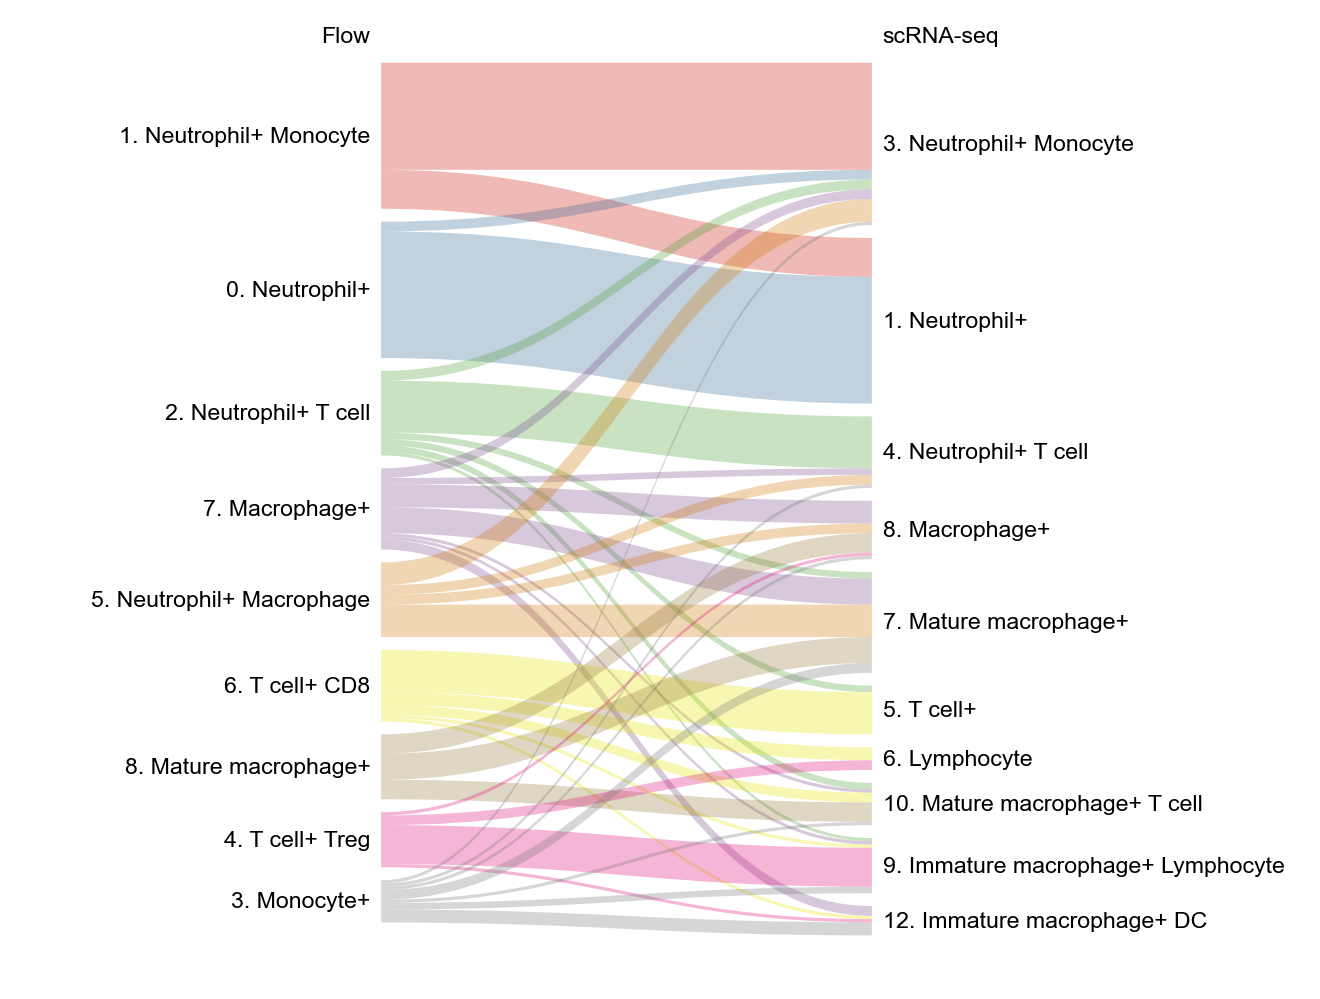

In [92]:
idx = full_df.ScRNAseq_clusters_names.notna()
fig = sankey.sankey(
    full_df.Flow_clusters_names[idx],
    full_df.ScRNAseq_clusters_names[idx],
    title_right='scRNA-seq',
    title_left='Flow'
);
fig.savefig('10Hd_scrnaseq_flow_sankey.pdf')

In [93]:
idx.sum()

233